In [1]:
# import necessary package
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# use correct device
if torch.cuda.is_available():
    device = torch.device("cuda:0") 
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [2]:
"""
Practice:
Same shape & channel basic block:

Let x.shape = (B, 32, 16, 16)
x => 
Residual Block: cnn (3x3, 32) => bn => relu => cnn(3x3, 32) => bn = F(x)

shape: (B, 32, 16, 16) => cnn+bn+relu(B, 32, 16, 16) => cnn+bn(B, 32, 16, 16) = F(x)

=> (B, 32, 16, 16) x + F(x)

...
=> max pooling (stride = 2) => continue
"""
# create basic block for resnet: channel => channel (same input and output channel)
class SameShapeBasicBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.residual_branch = nn.Sequential(
            nn.Conv2d(
                in_channels=channels,
                out_channels=channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(num_features=channels),
            nn.ReLU(),

            nn.Conv2d(
                in_channels=channels,
                out_channels=channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(num_features=channels)
        )

        self.relu = nn.ReLU()

    def forward(self, x):
        identity = x
        F_x = self.residual_branch(x)
        out = F_x + identity
        out = self.relu(out)

        return out
        

In [3]:
"""
General BasicBlock for ResNet
"""
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        # ===== Main residual branch F(x) =====
        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(
            num_features=out_channels
        )
        self.relu1 = nn.ReLU()

        # same shape basic block
        self.conv2 = nn.Conv2d(
            in_channels=out_channels, # channel remains same
            out_channels=out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(
            num_features=out_channels
        )


        # ===== identity x =====
        if (
            in_channels == out_channels
            and stride == 1
        ):
            self.shortcut = nn.Identity()

        # use 1x1 cnn to change shape of x to F(x)
        else:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=1,
                    stride=stride,
                    padding=0,
                    bias=False
                ),
                nn.BatchNorm2d(
                    num_features=out_channels
                )
            )
        
        self.relu = nn.ReLU()
    
    def forward(self, x):
        identity = self.shortcut(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.conv2(out)
        F_x = self.bn2(out)
        out = F_x + identity
        out = self.relu(out)
        return out

In [7]:
"""
Standard model processing
"""
# import necessary package
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# use correct device
if torch.cuda.is_available():
    device = torch.device("cuda:0") 
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

# setup hyperparameters
batch_size = 32
learning_rate = 0.001
num_epochs = 80

# setup transform of data: more generalized
train_transform = transforms.Compose([
    # pad 4px, then random crop back to 32x32
    # small random position shift
    transforms.RandomCrop(
        size=32,
        padding=4
    ),

    # horizontal flip with p=0.5
    transforms.RandomHorizontalFlip(),

    # PIL -> tensor, pixels in [0, 1]
    transforms.ToTensor(),

    # scale channels roughly from [0,1] to [-1,1]
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])


# prepare CIFAR10 dataset
train_source = datasets.CIFAR10(
    root="data/cifar10_raw",
    train=True,
    download=True,
    transform=train_transform
)
validation_source = datasets.CIFAR10(
    root="data/cifar10_raw",
    train=True,
    download=False,
    transform=eval_transform
)
test_source = datasets.CIFAR10(
    root="data/cifar10_raw",
    train=False,
    download=False,
    transform=eval_transform
)
# split training and validation data
validation_size = 5000 # train_size = len(train_source) - validation_size
split_generator = torch.Generator().manual_seed(42)
all_indices = torch.randperm(
    len(train_source),
    generator=split_generator
)

validation_indices = all_indices[:validation_size]
train_indices = all_indices[validation_size:]

train_dataset = Subset(
    train_source,
    train_indices.tolist()
)
validation_dataset = Subset(
    validation_source,
    validation_indices.tolist()
)

# organize to DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False
)
test_loader = DataLoader(
    test_source,
    batch_size=batch_size,
    shuffle=False
)



# define class:
class CIFAR10ResidualCNN(nn.Module):
    # initation --- layers setup
    def __init__(self):
        super().__init__()

        # ===== stem =====
        # shape: (B, 3, 32, 32) => (B, 32, 32, 32)
        self.stem = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(num_features=32),
            nn.ReLU(),
        )

        # ===== residual stage 1 =====
        # shape: (B, 32, 32, 32) => (B, 32, 32, 32)
        self.layer1 = nn.Sequential(
            BasicBlock(
                in_channels=32,
                out_channels=32,
                stride=1,
            ),
            BasicBlock(
                in_channels=32,
                out_channels=32,
                stride=1,
            )
        )

        # ===== residual stage 2 =====
        # shape: (B, 32, 32, 32) => (B, 64, 16, 16)
        self.layer2 = nn.Sequential(
            BasicBlock(
                in_channels=32,
                out_channels=64,
                stride=2,
            ),
            BasicBlock(
                in_channels=64,
                out_channels=64,
                stride=1
            )
        )

        # ===== residual stage 3 =====
        # shape: (B, 64, 16, 16) => (B, 128, 8, 8)
        self.layer3 = nn.Sequential(
            BasicBlock(
                in_channels=64,
                out_channels=128,
                stride=2,
            ),
            BasicBlock(
                in_channels=128,
                out_channels=128,
                stride=1,
            )
        )

        # ===== Global Average Pooling, Flatten, Linear =====
        # shape: (B, 128, 8, 8) => (B, 128, 1, 1)
        self.global_average_pool = (
            nn.AdaptiveAvgPool2d(
                output_size=(1, 1)
            )
        )
        # shape: (B, 128, 1, 1) => (B, 128)
        self.flatten = nn.Flatten()
        # shape: (B, 128) => (B, 10)
        self.output = nn.Linear(
            in_features=128,
            out_features=10
        )

    # put layers together
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.global_average_pool(x)
        x = self.flatten(x)
        logits = self.output(x)
        return logits

# create model --- setup loss function and optimizer
model = CIFAR10ResidualCNN().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    weight_decay=1e-4 # add weight_decay
) 

# Adjust learning rate
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    # watch validation loss (lower is better)
    mode="min",
    # on decay: new_lr = old_lr * 0.5
    factor=0.5,
    # decay if validation loss stalls for several epochs
    patience=4,
    # floor for learning rate
    min_lr=1e-5
)

# define training epoch function
def train_one_epoch(model, data_loader, loss_fn, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in data_loader:
        images = images.to(device) # default = cpu
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()
        # sum each batch's loss
        current_batch_size = labels.size(0)
        total_loss += loss.item() * current_batch_size # multiply current_batch_size because loss.item() is the average of a batch.
        predictions = logits.argmax(dim=1)
        total_correct += (predictions == labels).sum().item()
        total_samples += current_batch_size

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return average_loss, accuracy

# define evaluation function
def evaluate(model, data_loader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = loss_fn(logits, labels)
            predictions = logits.argmax(dim=1)
            # sum each batch's loss
            current_batch_size = labels.size(0)
            total_loss += loss.item() * current_batch_size
            total_correct += (predictions == labels).sum().item()
            total_samples += current_batch_size

        average_loss = total_loss / total_samples
        accuracy = total_correct / total_samples

    return average_loss, accuracy

# Save best model from validation datasets to "checkpoints"
from pathlib import Path
checkpoint_directory = Path("checkpoints")
checkpoint_directory.mkdir(
    parents=True,
    exist_ok=True
)
best_model_path = (
    checkpoint_directory /
    "best_cifar10_residual_cnn.pth"
)
best_validation_accuracy = 0.0
best_epoch = 0

# history record
history = {
    "train_loss": [],
    "train_accuracy": [],
    "validation_loss": [],
    "validation_accuracy": [],
    "learning_rate": []
}


for epoch in range(num_epochs):
    # lr used this epoch
    current_learning_rate = (
        optimizer.param_groups[0]["lr"]
    )

    # train one epoch
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        loss_fn,
        optimizer,
        device
    )

    # evaluate on validation set
    validation_loss, validation_accuracy = evaluate(
        model,
        validation_loader,
        loss_fn,
        device
    )

    # record history
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["validation_loss"].append(validation_loss)
    history["validation_accuracy"].append(validation_accuracy)
    history["learning_rate"].append(current_learning_rate)

    if validation_accuracy > best_validation_accuracy:
        best_validation_accuracy = validation_accuracy
        best_epoch = epoch + 1
        torch.save(
            model.state_dict(),
            best_model_path
        )
        print(f"Saved new best model at epoch {best_epoch}")

    # print progress
    print(
        f"Epoch {epoch + 1}/{num_epochs}: "
        f"lr={current_learning_rate:.6f}, "
        f"train loss={train_loss:.4f}, "
        f"train accuracy={train_accuracy:.2%}, "
        f"validation loss={validation_loss:.4f}, "
        f"validation accuracy="
        f"{validation_accuracy:.2%}"
    )

    # maybe decay lr on validation loss plateau
    scheduler.step(validation_loss)
    next_learning_rate = (
        optimizer.param_groups[0]["lr"]
    )  # lr after scheduler step
    if next_learning_rate < current_learning_rate:
        print(
            "Learning rate reduced: "
            f"{current_learning_rate:.6f} "
            f"-> {next_learning_rate:.6f}"
        )

# Use best model's parameters for test datasets
# Create same structure but with use different state of parameters
best_model = CIFAR10ResidualCNN() 
best_model_state = torch.load(
    best_model_path,
    map_location="cpu",
    weights_only=True
)
best_model.load_state_dict(
    best_model_state
)
best_model = best_model.to(device)
print("Best validation epoch:", best_epoch)
print(
    "Best validation accuracy:",
    f"{best_validation_accuracy:.2%}"
)


# test datasets
test_loss, test_accuracy = evaluate(
    best_model,
    test_loader,
    loss_fn,
    device
)
print("\nFinal test result:")
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

Using device: mps
Files already downloaded and verified
Saved new best model at epoch 1
Epoch 1/80: lr=0.001000, train loss=1.4810, train accuracy=45.35%, validation loss=1.1844, validation accuracy=58.40%
Saved new best model at epoch 2
Epoch 2/80: lr=0.001000, train loss=1.0385, train accuracy=62.94%, validation loss=1.0029, validation accuracy=65.96%
Saved new best model at epoch 3
Epoch 3/80: lr=0.001000, train loss=0.8678, train accuracy=69.35%, validation loss=0.8161, validation accuracy=71.48%
Saved new best model at epoch 4
Epoch 4/80: lr=0.001000, train loss=0.7384, train accuracy=74.42%, validation loss=0.7177, validation accuracy=75.84%
Saved new best model at epoch 5
Epoch 5/80: lr=0.001000, train loss=0.6583, train accuracy=77.27%, validation loss=0.5762, validation accuracy=80.06%
Epoch 6/80: lr=0.001000, train loss=0.5946, train accuracy=79.62%, validation loss=0.7561, validation accuracy=76.22%
Saved new best model at epoch 7
Epoch 7/80: lr=0.001000, train loss=0.5546, 

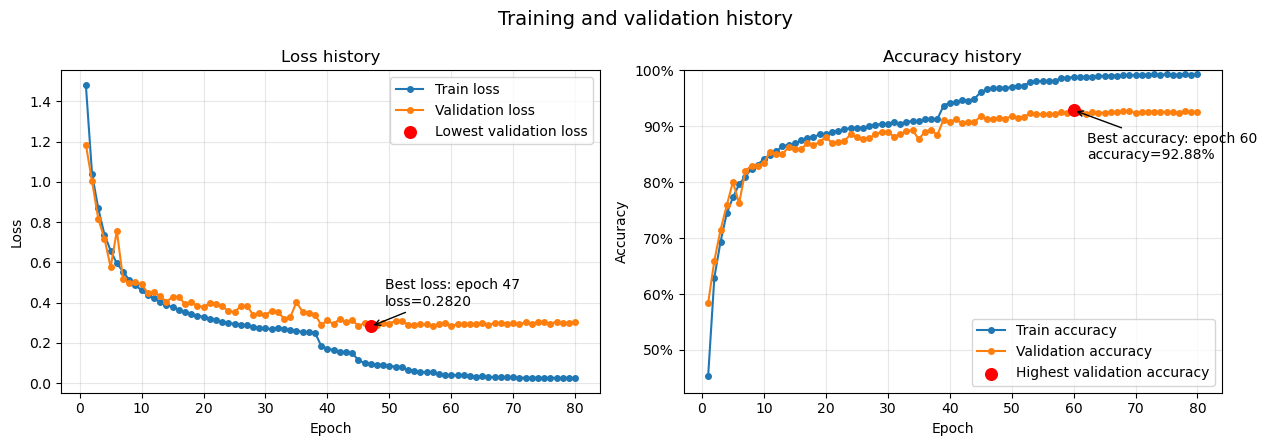

In [8]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter


# plot only completed epochs
# with early stopping, may stop before num_epochs
epochs = range(
    1,
    len(history["train_loss"]) + 1
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5)
)


# ============================================================
# Left plot: Train loss vs Validation loss
# ============================================================

axes[0].plot(
    epochs,
    history["train_loss"],
    marker="o",
    markersize=4,
    label="Train loss"
)

axes[0].plot(
    epochs,
    history["validation_loss"],
    marker="o",
    markersize=4,
    label="Validation loss"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss history")
axes[0].grid(alpha=0.3)


# ------------------------------------------------------------
# find epoch with lowest validation loss
# ------------------------------------------------------------

best_loss_index = history["validation_loss"].index(
    min(history["validation_loss"])
)

# index 0-based -> epoch 1-based
best_loss_epoch = best_loss_index + 1

best_validation_loss = history["validation_loss"][
    best_loss_index
]


# mark lowest validation loss
axes[0].scatter(
    best_loss_epoch,
    best_validation_loss,
    color="red",
    s=70,
    zorder=3,
    label="Lowest validation loss"
)

axes[0].annotate(
    f"Best loss: epoch {best_loss_epoch}\n"
    f"loss={best_validation_loss:.4f}",

    xy=(
        best_loss_epoch,
        best_validation_loss
    ),

    xytext=(10, 15),
    textcoords="offset points",

    arrowprops={
        "arrowstyle": "->"
    }
)

# legend after all artists
axes[0].legend()


# ============================================================
# Right plot: Train accuracy vs Validation accuracy
# ============================================================

axes[1].plot(
    epochs,
    history["train_accuracy"],
    marker="o",
    markersize=4,
    label="Train accuracy"
)

axes[1].plot(
    epochs,
    history["validation_accuracy"],
    marker="o",
    markersize=4,
    label="Validation accuracy"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy history")
axes[1].grid(alpha=0.3)


# show 0.75 as 75%
axes[1].yaxis.set_major_formatter(
    PercentFormatter(xmax=1.0)
)


# ------------------------------------------------------------
# zoom y-axis to accuracy range
# ------------------------------------------------------------

all_accuracies = (
    history["train_accuracy"]
    + history["validation_accuracy"]
)

accuracy_min = max(
    0.0,
    min(all_accuracies) - 0.03
)

accuracy_max = min(
    1.0,
    max(all_accuracies) + 0.03
)

axes[1].set_ylim(
    accuracy_min,
    accuracy_max
)


# ------------------------------------------------------------
# find epoch with highest validation accuracy
# ------------------------------------------------------------

best_accuracy_index = (
    history["validation_accuracy"].index(
        max(history["validation_accuracy"])
    )
)

best_accuracy_epoch = (
    best_accuracy_index + 1
)

best_validation_accuracy_from_history = (
    history["validation_accuracy"][
        best_accuracy_index
    ]
)


# mark best validation accuracy
axes[1].scatter(
    best_accuracy_epoch,
    best_validation_accuracy_from_history,
    color="red",
    s=70,
    zorder=3,
    label="Highest validation accuracy"
)

axes[1].annotate(
    f"Best accuracy: epoch {best_accuracy_epoch}\n"
    f"accuracy="
    f"{best_validation_accuracy_from_history:.2%}",

    xy=(
        best_accuracy_epoch,
        best_validation_accuracy_from_history
    ),

    xytext=(10, -35),
    textcoords="offset points",

    arrowprops={
        "arrowstyle": "->"
    }
)

axes[1].legend()


# ============================================================
# Final layout
# ============================================================

fig.suptitle(
    "Training and validation history",
    fontsize=14
)

fig.tight_layout()

plt.show()

In [9]:
"""
General Bottleneck Structure for ResNet
"""
class Bottleneck(nn.Module):
    # out_channels = 4 * mid_channels
    expansion = 4

    def __init__(self, in_channels, bottleneck_channels, stride=1):
        super().__init__()
        out_channels = (bottleneck_channels * self.expansion)

        # ===== Main residual branch F(x) =====
        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=bottleneck_channels, # make sure it goes to a "bottleneck" shape
            kernel_size=1,
            stride=1,
            padding=0,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(
            num_features=bottleneck_channels
        )
        self.relu1 = nn.ReLU()

        # same shape basic block
        self.conv2 = nn.Conv2d(
            in_channels=bottleneck_channels, # channel remains same
            out_channels=bottleneck_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(
            num_features=bottleneck_channels
        )
        self.relu2 = nn.ReLU()

        # bottleneck end
        self.conv3 = nn.Conv2d(
            in_channels=bottleneck_channels, # channel remains same
            out_channels=out_channels,
            kernel_size=1,
            stride=1,
            padding=0,
            bias=False
        )
        self.bn3 = nn.BatchNorm2d(
            num_features=out_channels
        )

        # ===== identity x =====
        if (
            in_channels == out_channels
            and stride == 1
        ):
            self.shortcut = nn.Identity()

        # use 1x1 cnn to change shape of x to F(x)
        else:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=1,
                    stride=stride,
                    padding=0,
                    bias=False
                ),
                nn.BatchNorm2d(
                    num_features=out_channels
                )
            )
        
        self.relu = nn.ReLU()
    
    def forward(self, x):
        identity = self.shortcut(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu2(out)

        out = self.conv3(out)
        F_x = self.bn3(out)

        out = F_x + identity
        out = self.relu(out)
        return out

In [10]:
"""
Standard model processing
"""
# import necessary package
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# use correct device
if torch.cuda.is_available():
    device = torch.device("cuda:0") 
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

# setup hyperparameters
batch_size = 32
learning_rate = 0.001
num_epochs = 60

# setup transform of data: more generalized
train_transform = transforms.Compose([
    # pad 4px, then random crop back to 32x32
    # small random position shift
    transforms.RandomCrop(
        size=32,
        padding=4
    ),

    # horizontal flip with p=0.5
    transforms.RandomHorizontalFlip(),

    # PIL -> tensor, pixels in [0, 1]
    transforms.ToTensor(),

    # scale channels roughly from [0,1] to [-1,1]
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])


# prepare CIFAR10 dataset
train_source = datasets.CIFAR10(
    root="data/cifar10_raw",
    train=True,
    download=True,
    transform=train_transform
)
validation_source = datasets.CIFAR10(
    root="data/cifar10_raw",
    train=True,
    download=False,
    transform=eval_transform
)
test_source = datasets.CIFAR10(
    root="data/cifar10_raw",
    train=False,
    download=False,
    transform=eval_transform
)
# split training and validation data
validation_size = 5000 # train_size = len(train_source) - validation_size
split_generator = torch.Generator().manual_seed(42)
all_indices = torch.randperm(
    len(train_source),
    generator=split_generator
)

validation_indices = all_indices[:validation_size]
train_indices = all_indices[validation_size:]

train_dataset = Subset(
    train_source,
    train_indices.tolist()
)
validation_dataset = Subset(
    validation_source,
    validation_indices.tolist()
)

# organize to DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False
)
test_loader = DataLoader(
    test_source,
    batch_size=batch_size,
    shuffle=False
)



# define class:
class CIFAR10BottleneckResNet(nn.Module):
    # initation --- layers setup
    def __init__(self):
        super().__init__()

        # ===== stem =====
        # shape: (B, 3, 32, 32) => (B, 64, 32, 32)
        self.stem = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=64,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(num_features=64),
            nn.ReLU(),
        )

        # ===== residual stage 1 =====

            # shape: (B, 64, 32, 32) => (B, 128, 32, 32)
        self.layer1 = nn.Sequential(
            Bottleneck(
                in_channels=64,
                bottleneck_channels=32,
                stride=1
            ),
            Bottleneck(
                in_channels=128,
                bottleneck_channels=32,
                stride=1
            )
        )
        
        
        # ===== residual stage 2 =====
        # shape: (B, 128, 32, 32) => (B, 256, 16, 16)
        self.layer2 = nn.Sequential(
            Bottleneck(
                in_channels=128,
                bottleneck_channels=64,
                stride=2 # downsampling
            ),
            Bottleneck(
                in_channels=256,
                bottleneck_channels=64,
                stride=1
            )
        )

        # ===== residual stage 3 =====
        # shape: (B, 256, 16, 16) => (B, 512, 8, 8)
        self.layer3 = nn.Sequential(
            Bottleneck(
                in_channels=256,
                bottleneck_channels=128,
                stride=2 # downsampling
            ),
            Bottleneck(
                in_channels=512,
                bottleneck_channels=128,
                stride=1
            )
        )

        # ===== Global Average Pooling, Flatten, Linear =====
        # shape: (B, 512, 8, 8) => (B, 512, 1, 1)
        self.global_average_pool = (
            nn.AdaptiveAvgPool2d(
                output_size=(1, 1)
            )
        )
        # shape: (B, 512, 1, 1) => (B, 512)
        self.flatten = nn.Flatten()
        # shape: (B, 512) => (B, 10)
        self.output = nn.Linear(
            in_features=512,
            out_features=10
        )

    # put layers together
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.global_average_pool(x)
        x = self.flatten(x)
        logits = self.output(x)
        return logits

# create model --- setup loss function and optimizer
model = CIFAR10BottleneckResNet().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    weight_decay=1e-4 # add weight_decay
) 

# Adjust learning rate
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    # watch validation loss (lower is better)
    mode="min",
    # on decay: new_lr = old_lr * 0.5
    factor=0.5,
    # decay if validation loss stalls for several epochs
    patience=4,
    # floor for learning rate
    min_lr=1e-5
)

# define training epoch function
def train_one_epoch(model, data_loader, loss_fn, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in data_loader:
        images = images.to(device) # default = cpu
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()
        # sum each batch's loss
        current_batch_size = labels.size(0)
        total_loss += loss.item() * current_batch_size # multiply current_batch_size because loss.item() is the average of a batch.
        predictions = logits.argmax(dim=1)
        total_correct += (predictions == labels).sum().item()
        total_samples += current_batch_size

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return average_loss, accuracy

# define evaluation function
def evaluate(model, data_loader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = loss_fn(logits, labels)
            predictions = logits.argmax(dim=1)
            # sum each batch's loss
            current_batch_size = labels.size(0)
            total_loss += loss.item() * current_batch_size
            total_correct += (predictions == labels).sum().item()
            total_samples += current_batch_size

        average_loss = total_loss / total_samples
        accuracy = total_correct / total_samples

    return average_loss, accuracy

# Save best model from validation datasets to "checkpoints"
from pathlib import Path
checkpoint_directory = Path("checkpoints")
checkpoint_directory.mkdir(
    parents=True,
    exist_ok=True
)
best_model_path = (
    checkpoint_directory /
    "best_cifar10_bottleneck_resnet.pth"
)
best_validation_accuracy = 0.0
best_epoch = 0

# history record
history = {
    "train_loss": [],
    "train_accuracy": [],
    "validation_loss": [],
    "validation_accuracy": [],
    "learning_rate": []
}


for epoch in range(num_epochs):
    # lr used this epoch
    current_learning_rate = (
        optimizer.param_groups[0]["lr"]
    )

    # train one epoch
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        loss_fn,
        optimizer,
        device
    )

    # evaluate on validation set
    validation_loss, validation_accuracy = evaluate(
        model,
        validation_loader,
        loss_fn,
        device
    )

    # record history
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["validation_loss"].append(validation_loss)
    history["validation_accuracy"].append(validation_accuracy)
    history["learning_rate"].append(current_learning_rate)

    if validation_accuracy > best_validation_accuracy:
        best_validation_accuracy = validation_accuracy
        best_epoch = epoch + 1
        torch.save(
            model.state_dict(),
            best_model_path
        )
        print(f"Saved new best model at epoch {best_epoch}")

    # print progress
    print(
        f"Epoch {epoch + 1}/{num_epochs}: "
        f"lr={current_learning_rate:.6f}, "
        f"train loss={train_loss:.4f}, "
        f"train accuracy={train_accuracy:.2%}, "
        f"validation loss={validation_loss:.4f}, "
        f"validation accuracy="
        f"{validation_accuracy:.2%}"
    )

    # maybe decay lr on validation loss plateau
    scheduler.step(validation_loss)
    next_learning_rate = (
        optimizer.param_groups[0]["lr"]
    )  # lr after scheduler step
    if next_learning_rate < current_learning_rate:
        print(
            "Learning rate reduced: "
            f"{current_learning_rate:.6f} "
            f"-> {next_learning_rate:.6f}"
        )

# Use best model's parameters for test datasets
# Create same structure but with use different state of parameters
best_model = CIFAR10BottleneckResNet() 
best_model_state = torch.load(
    best_model_path,
    map_location="cpu",
    weights_only=True
)
best_model.load_state_dict(
    best_model_state
)
best_model = best_model.to(device)
print("Best validation epoch:", best_epoch)
print(
    "Best validation accuracy:",
    f"{best_validation_accuracy:.2%}"
)


# test datasets
test_loss, test_accuracy = evaluate(
    best_model,
    test_loader,
    loss_fn,
    device
)
print("\nFinal test result:")
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

Using device: mps
Files already downloaded and verified
Saved new best model at epoch 1
Epoch 1/60: lr=0.001000, train loss=1.3976, train accuracy=48.84%, validation loss=1.1522, validation accuracy=60.86%
Saved new best model at epoch 2
Epoch 2/60: lr=0.001000, train loss=1.0222, train accuracy=63.52%, validation loss=0.9447, validation accuracy=68.12%
Saved new best model at epoch 3
Epoch 3/60: lr=0.001000, train loss=0.8850, train accuracy=68.71%, validation loss=0.8990, validation accuracy=69.12%
Saved new best model at epoch 4
Epoch 4/60: lr=0.001000, train loss=0.7910, train accuracy=72.28%, validation loss=0.8235, validation accuracy=72.10%
Saved new best model at epoch 5
Epoch 5/60: lr=0.001000, train loss=0.7185, train accuracy=74.71%, validation loss=0.6847, validation accuracy=76.24%
Saved new best model at epoch 6
Epoch 6/60: lr=0.001000, train loss=0.6616, train accuracy=76.95%, validation loss=0.5917, validation accuracy=79.58%
Saved new best model at epoch 7
Epoch 7/60: 

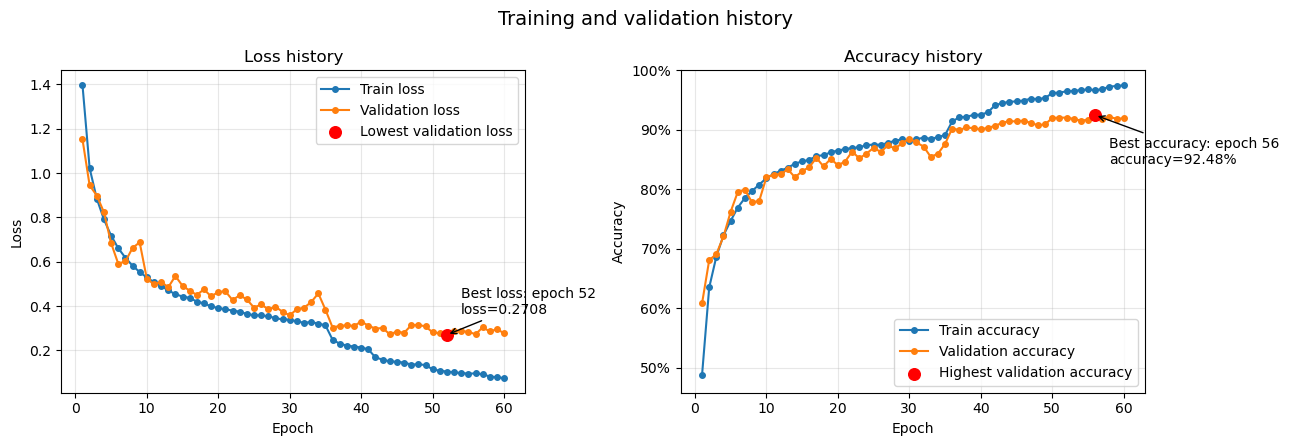

In [11]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter


# plot only completed epochs
# with early stopping, may stop before num_epochs
epochs = range(
    1,
    len(history["train_loss"]) + 1
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5)
)


# ============================================================
# Left plot: Train loss vs Validation loss
# ============================================================

axes[0].plot(
    epochs,
    history["train_loss"],
    marker="o",
    markersize=4,
    label="Train loss"
)

axes[0].plot(
    epochs,
    history["validation_loss"],
    marker="o",
    markersize=4,
    label="Validation loss"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss history")
axes[0].grid(alpha=0.3)


# ------------------------------------------------------------
# find epoch with lowest validation loss
# ------------------------------------------------------------

best_loss_index = history["validation_loss"].index(
    min(history["validation_loss"])
)

# index 0-based -> epoch 1-based
best_loss_epoch = best_loss_index + 1

best_validation_loss = history["validation_loss"][
    best_loss_index
]


# mark lowest validation loss
axes[0].scatter(
    best_loss_epoch,
    best_validation_loss,
    color="red",
    s=70,
    zorder=3,
    label="Lowest validation loss"
)

axes[0].annotate(
    f"Best loss: epoch {best_loss_epoch}\n"
    f"loss={best_validation_loss:.4f}",

    xy=(
        best_loss_epoch,
        best_validation_loss
    ),

    xytext=(10, 15),
    textcoords="offset points",

    arrowprops={
        "arrowstyle": "->"
    }
)

# legend after all artists
axes[0].legend()


# ============================================================
# Right plot: Train accuracy vs Validation accuracy
# ============================================================

axes[1].plot(
    epochs,
    history["train_accuracy"],
    marker="o",
    markersize=4,
    label="Train accuracy"
)

axes[1].plot(
    epochs,
    history["validation_accuracy"],
    marker="o",
    markersize=4,
    label="Validation accuracy"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy history")
axes[1].grid(alpha=0.3)


# show 0.75 as 75%
axes[1].yaxis.set_major_formatter(
    PercentFormatter(xmax=1.0)
)


# ------------------------------------------------------------
# zoom y-axis to accuracy range
# ------------------------------------------------------------

all_accuracies = (
    history["train_accuracy"]
    + history["validation_accuracy"]
)

accuracy_min = max(
    0.0,
    min(all_accuracies) - 0.03
)

accuracy_max = min(
    1.0,
    max(all_accuracies) + 0.03
)

axes[1].set_ylim(
    accuracy_min,
    accuracy_max
)


# ------------------------------------------------------------
# find epoch with highest validation accuracy
# ------------------------------------------------------------

best_accuracy_index = (
    history["validation_accuracy"].index(
        max(history["validation_accuracy"])
    )
)

best_accuracy_epoch = (
    best_accuracy_index + 1
)

best_validation_accuracy_from_history = (
    history["validation_accuracy"][
        best_accuracy_index
    ]
)


# mark best validation accuracy
axes[1].scatter(
    best_accuracy_epoch,
    best_validation_accuracy_from_history,
    color="red",
    s=70,
    zorder=3,
    label="Highest validation accuracy"
)

axes[1].annotate(
    f"Best accuracy: epoch {best_accuracy_epoch}\n"
    f"accuracy="
    f"{best_validation_accuracy_from_history:.2%}",

    xy=(
        best_accuracy_epoch,
        best_validation_accuracy_from_history
    ),

    xytext=(10, -35),
    textcoords="offset points",

    arrowprops={
        "arrowstyle": "->"
    }
)

axes[1].legend()


# ============================================================
# Final layout
# ============================================================

fig.suptitle(
    "Training and validation history",
    fontsize=14
)

fig.tight_layout()

plt.show()